In [17]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('googleplaystore.csv')
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [19]:
df = df.dropna()
df = df.drop_duplicates()

print("Trash cleared. Current shape of dataset:", df.shape)


Trash cleared. Current shape of dataset: (8886, 13)


In [20]:
df['Installs'] = df['Installs'].str.replace('+', '')

df['Installs'] = df['Installs'].str.replace(',', '')

df['Installs'] = df['Installs'].astype(int)

print("Installs column is now clean ")

Installs column is now clean 


In [22]:

df['Price'] = df['Price'].str.replace('$', '')

df['Price'] = df['Price'].astype(float)

print("Price column is now clean math data!")

Price column is now clean math data!


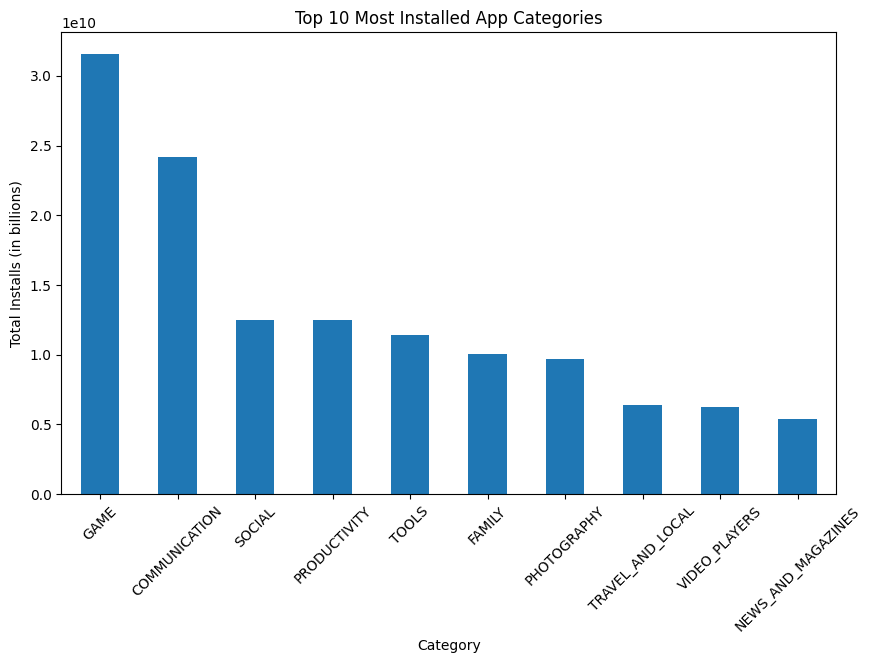

In [ ]:

top_categories = df.groupby('Category')['Installs'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
top_categories.plot(kind='bar')
plt.title('Top 10 Most Installed App Categories')
plt.ylabel('Total Installs (in billions)')
plt.xticks(rotation=45)
plt.show()

In [25]:
import numpy as np

# Force the Reviews column to become numeric math data
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
print("Reviews column is clean")

Reviews column is clean


WROTE A FUNCTION BLOCK TO CLEAN THE CONFUSION OF APP SIZE IN DIFFERENT UNITS

In [23]:

def clean_size(size_str):
    size_str = str(size_str) 
    
    if 'Varies with device' in size_str:
        return np.nan 
        
    elif 'M' in size_str:
        return float(size_str.replace('M', ''))
        
    elif 'k' in size_str:
        return float(size_str.replace('k', '')) / 1024
        
    else:
        return np.nan


df['Size'] = df['Size'].apply(clean_size)

print("Size column is now standardized to Megabytes")

Size column is now standardized to Megabytes


In [24]:
df = df.dropna()
print(" Dataset is 100% pure math and clean text")

 Dataset is 100% pure math and clean text


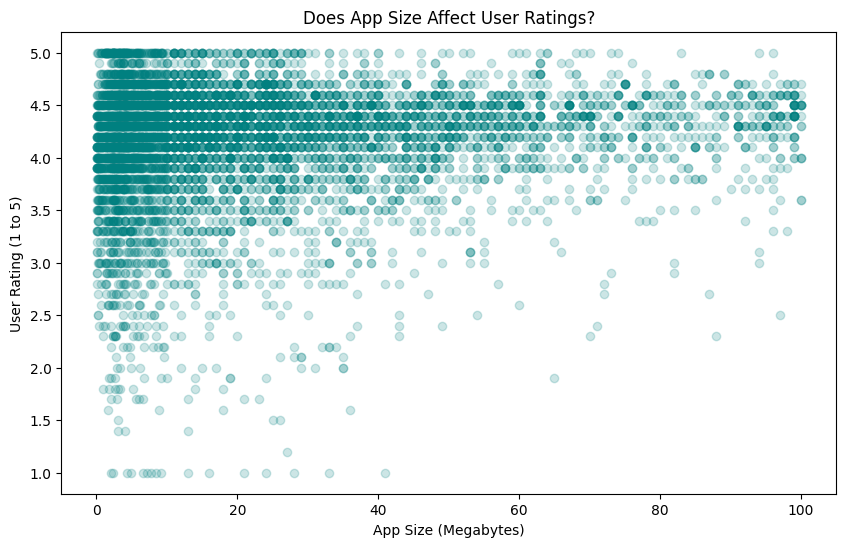

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Size'], df['Rating'], alpha=0.2, color='teal')
plt.title('Does App Size Affect User Ratings?')
plt.xlabel('App Size (Megabytes)')
plt.ylabel('User Rating (1 to 5)')
plt.show()

In [16]:
# Grab 10 completely random rows from anywhere in the dataset
df.sample(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
8650,To-Do List Widget,PRODUCTIVITY,3.9,7801,0.196289,1000000,Free,0.0,Everyone,Productivity,"September 28, 2013",2.0,1.5 and up
300,Röhrich Werner Soundboard,COMICS,4.7,2249,32.000000,500000,Free,0.0,Everyone,Comics,"November 16, 2017",1.08,4.0.3 and up
8859,DT Baby Cam,TOOLS,1.7,10,23.000000,500,Free,0.0,Everyone,Tools,"December 5, 2017",3.0,2.2 and up
3918,Law of Creation: A Playable Manga,GAME,4.5,13118,47.000000,500000,Free,0.0,Teen,Adventure,"June 25, 2018",1.0.19,4.0.3 and up
5244,AJ Player,VIDEO_PLAYERS,4.8,18,1.700000,100,Free,0.0,Everyone,Video Players & Editors,"April 22, 2018",1.6.3.1,5.0 and up
1518,SUDOKU,LIBRARIES_AND_DEMO,4.1,923,4.300000,100000,Free,0.0,Everyone,Libraries & Demo,"October 15, 2015",3.1,2.3 and up
2533,Zen Leaf,MEDICAL,5.0,1,6.100000,100,Free,0.0,Mature 17+,Medical,"March 8, 2018",2.3.5,4.1 and up
3055,"theScore: Live Sports Scores, News, Stats & Vi...",SPORTS,4.4,133833,34.000000,10000000,Free,0.0,Everyone 10+,Sports,"July 25, 2018",6.17.2,4.4 and up
257,ScreenMeet. Easy Phone Meeting,BUSINESS,4.0,624,9.000000,100000,Free,0.0,Everyone,Business,"March 22, 2018",1.2.287,5.0 and up
8957,DV Lottery Simulator,FAMILY,4.6,13,1.300000,1000,Free,0.0,Everyone,Entertainment,"October 20, 2016",1.1,4.1 and up
